In [14]:
import cv2
import time
import random
from random import sample

from matplotlib import pyplot as plt
import math
import os
import numpy as np

import mediapipe as mp
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler


In [15]:
align_file_test = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S1/align/bbaf2s.align" 


def ParseAlign(align_file: str)-> list[bool, int, int]:
    """
    Provides Clip information for a single .align file
    Args:
        align_file: path to align file
    Returns:
        clip_alignments: [[sil,start_frame,end_frame],[sil,start_frame end_frame],[talking,start_frame,end_frame],[talking,start_frame,end_frame]]
    """

    with open(align_file, 'r') as file:
        clip_alignment = []
        start_talk=0
        end_talk=0
        for line in file:
            alignment = line.strip('\n').split(" ")
            start, end, word = alignment
            if word == "sil":
                start_frame = math.ceil(int(start)*0.001)
                end_frame = math.ceil(int(end)*0.001)
                clip_alignment.append(["sil", start_frame, end_frame])
                
            else:
                if start_talk == 0:
                    start_talk = math.ceil(int(start)*0.001)
                if math.ceil(int(end)*0.001) > end_talk:
                    end_talk = math.ceil(int(end)*0.001)
        midpoint = math.ceil(start_talk + (end_talk-start_talk)/2)
        clip_alignment.append(["talking", start_talk, midpoint])
        clip_alignment.append(["talking", midpoint, end_talk])
            

    return clip_alignment

ParseAlign(align_file=align_file_test)

[['sil', 0, 13], ['sil', 51, 75], ['talking', 13, 32], ['talking', 32, 51]]

In [16]:
FULL_GRID_DIR = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata"

def ParseDataset(path: str) -> list[bool, int, int, str]:
    """Given a formatted dataset, returns all clip infromation
    Args:
        path: path to dataset
    Returns:
        clip_alignments: [istalking: bool,start_frame:int,end_frame:int, videopath:str]"""

    dataset_abstracted = []
    for subject in os.listdir(path):
        try:
            align_folder = path + "/" + subject + "/align"
            video_folder = path + "/" + subject + "/" + subject
            for filename in os.listdir(align_folder):
                video_clip_name = filename.split(".")[0]+".mpg"
                video_path = video_folder + "/"+ video_clip_name
                alignments = ParseAlign(align_folder+"/"+filename)
                if os.path.isfile(video_path): #Try video path except skip
                    for alignment in alignments:
                        clip_values = [*alignment, video_path]
                        dataset_abstracted.append(clip_values)

        except Exception as e:
            print("Exception Error:", e)

    return dataset_abstracted

dataset_values = ParseDataset(FULL_GRID_DIR)
print(dataset_values[0])



['sil', 0, 14, '/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S4/S4/bbae9n.mpg']


In [17]:
MOUTH_LANDMARKS = [0, 267, 269, 270, 409, 306, 375, 321, 405, 314, 17, 84, 181, 91, 146, 61, 185, 40, 39,
                                37]

mpDraw = mp.solutions.drawing_utils
mpFaceMesh = mp.solutions.face_mesh
faceMesh = mpFaceMesh.FaceMesh(max_num_faces=2)
drawSpec = mpDraw.DrawingSpec(thickness=1, circle_radius=1)

def FindMouth(img, output_format):
    landmarks = []
    radiandistance = []
    try:
        results = faceMesh.process(img)
        if results.multi_face_landmarks:
            for faceLms in results.multi_face_landmarks:
                # mpDraw.draw_landmarks(img, faceLms, mpFaceMesh.FACEMESH_CONTOURS, drawSpec, drawSpec)
                for id,lm in enumerate(faceLms.landmark):
                    image_height, image_width, image_channels = img.shape
                    x,y = int(lm.x*image_width), int(lm.y*image_height)
                    if output_format == "mouthrgb":
                        if id == 0:
                            return img[y-40:y+60,x-50:x+50,:]
                    if output_format == "liplandmarks":
                        if id in MOUTH_LANDMARKS:
                            landmarks.append((x,y))
            if landmarks:
                for x,y in landmarks:
                    x2,y2 = landmarks[0]
                    deltaX, deltaY = ((x2-x)**2), ((y2-y)**2)
                    radian = math.atan2(deltaY, deltaX)
                    radiandistance.append((math.dist((x,y),(x2,y2)), radian))
                return radiandistance
    except Exception as e:
        print("Failed to FindMouth:", e)
    return None
        

I0000 00:00:1743004970.504360  852601 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1743004970.625797  855496 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.120), renderer: NVIDIA GeForce RTX 4070/PCIe/SSE2
W0000 00:00:1743004970.629982  855484 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [18]:
# frameformats -> mouthrgb, mouthgreyscale, liplandmarks, fullframe/face



class FrameGenerator():
    """Given an array of dataset values, returns labeled and formatted data/frames"""
    def __init__(self, dataset_values, training=False, frame_format="mouthrgb"):
        self.dataset_values = dataset_values
        self.training = training
        self.frame_format = frame_format
        
        match self.frame_format:
            case "mouthrgb":
                self.input_shape = (10, 100, 100, 3)
            case "liplandmarks":
                self.input_shape = (10, 20, 2)
                


    def __call__(self):
        if self.training:
            np.random.shuffle(self.dataset_values) #Use a different shuffle method?
            # print((self.dataset_values[0]))

        FailedReads = 0
        SuccessfullReads = 0
        ShapeIssues = 0

        # print("Test dataset format" ,self.dataset_values)
        for isTalking, start_frame, end_frame, video_path in self.dataset_values:
            label = np.int16(0 if isTalking == "sil" else 1) 
            formatted_frames = []

            cap = cv2.VideoCapture(video_path)
            count = 0
            while count < self.input_shape[0]:
                cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame+count)
                ret, frame = cap.read()
                if not ret:
                    # print("failed to read: " + video_path + str(count))
                    FailedReads += 1
                    # time.sleep(1)
                    formatted_frames.append(np.zeros((self.input_shape[1],self.input_shape[2]), dtype=np.float32))
                else:
                    SuccessfullReads += 1
                    frame = FindMouth(frame, self.frame_format)
                    if frame is None:
                        formatted_frames.append(np.zeros((self.input_shape[1],self.input_shape[2]), dtype=np.float32))
                    else:
                        if self.frame_format == "mouthrgb":
                            frame = frame / 255
                            frame = tf.image.resize_with_pad(frame,self.input_shape[1],self.input_shape[2]) 
                            frame = tf.image.convert_image_dtype(frame, tf.float32)
                        if self.frame_format == "liplandmarks":
                            frame = np.array(frame, dtype=np.float32)
                            pass
                        if frame.shape == (self.input_shape[1],self.input_shape[2]):
                            formatted_frames.append(frame)
                        else:
                            ShapeIssues += 1
                count += 1

            cap.release()

            while len(formatted_frames) < 10:
                formatted_frames.append(np.zeros((self.input_shape[1], self.input_shape[2]), dtype=np.float32))

            formatted_frames = np.array(formatted_frames, dtype=np.float32)
            # print(formatted_frames)
            # if self.frame_format == "mouthrgb":
            #     formatted_frames = np.array(formatted_frames)[...,[2,1,0]]
            print("Successful Reads:", SuccessfullReads, "Failed Reads:", FailedReads, "Shape Issues:", ShapeIssues)
            yield formatted_frames, label

    




print(len(dataset_values))
train_dataset_values = sample(dataset_values, 80000)
val_dataset_values = sample(dataset_values, 20000)
print(len(train_dataset_values), len(val_dataset_values))                    

fg = FrameGenerator(dataset_values, True, "liplandmarks")

first_item, label = next(fg())

print(first_item.shape, label)
# print(label)        

120000
8000 2000


W0000 00:00:1743004970.643647  855485 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Successful Reads: 10 Failed Reads: 0 Shape Issues: 0
(10, 20, 2) 1


In [19]:
# train_ds = train_ds.batch(2)
# val_ds = val_ds.batch(2)

input_shape = (10, 20, 2)

output_signature = (tf.TensorSpec(shape = input_shape, dtype = tf.float32, name="frames"),
                    tf.TensorSpec(shape = (), dtype = tf.int16, name="labels"))
train_ds = tf.data.Dataset.from_generator(FrameGenerator(train_dataset_values, True, "liplandmarks"),
                                          output_signature = output_signature)
val_ds = tf.data.Dataset.from_generator(FrameGenerator(val_dataset_values, True, "liplandmarks"),
                                          output_signature = output_signature)

print(train_ds)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)
print(train_ds)
val_ds = val_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)

<_FlatMapDataset element_spec=(TensorSpec(shape=(10, 20, 2), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(10, 20, 2), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>


In [20]:
train_ds = train_ds.batch(2)
val_ds = val_ds.batch(2)

# print("Frames shape:", frames.shape)  # Should be (10, 100, 100, 3)
# print("Labels:", labels)  # Should be a single int16 label
for i in range(10):
    print(train_ds.take(i))

<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 20, 2), dtype=tf.float32, name=None), TensorSpec(s

In [21]:



model = models.Sequential([

    TimeDistributed(Flatten(), input_shape=input_shape),
        
    # Bidirectional LSTM to capture temporal patterns in lip movements
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    
    # Second LSTM layer to further process the sequence
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Dense layers for classification
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification (talking or not)
    # Change from softmax to sigmoid
])

# Compile Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),  # Change loss function
              metrics=['accuracy'])

# Model Summary
history = model.fit(train_ds, 
          epochs = 50,
          validation_data = val_ds,
          callbacks = tf.keras.callbacks.EarlyStopping(patience = 5, monitor = 'val_loss'))

Epoch 1/50
Successful Reads: 10 Failed Reads: 0 Shape Issues: 0
Successful Reads: 20 Failed Reads: 0 Shape Issues: 0
Successful Reads: 30 Failed Reads: 0 Shape Issues: 0
Successful Reads: 40 Failed Reads: 0 Shape Issues: 0
Successful Reads: 50 Failed Reads: 0 Shape Issues: 0
Successful Reads: 60 Failed Reads: 0 Shape Issues: 0
Successful Reads: 70 Failed Reads: 0 Shape Issues: 0
Successful Reads: 80 Failed Reads: 0 Shape Issues: 0
Successful Reads: 90 Failed Reads: 0 Shape Issues: 0
Successful Reads: 100 Failed Reads: 0 Shape Issues: 0
Successful Reads: 110 Failed Reads: 0 Shape Issues: 0
Successful Reads: 120 Failed Reads: 0 Shape Issues: 0
Successful Reads: 130 Failed Reads: 0 Shape Issues: 0
Successful Reads: 140 Failed Reads: 0 Shape Issues: 0
Successful Reads: 150 Failed Reads: 0 Shape Issues: 0
Successful Reads: 160 Failed Reads: 0 Shape Issues: 0
Successful Reads: 170 Failed Reads: 0 Shape Issues: 0
Successful Reads: 180 Failed Reads: 0 Shape Issues: 0
Successful Reads: 190 Fail

2025-03-26 16:03:04.854171: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:28: Filling up shuffle buffer (this may take a while): 91 of 1000


Successful Reads: 902 Failed Reads: 18 Shape Issues: 0
Successful Reads: 912 Failed Reads: 18 Shape Issues: 0
Successful Reads: 922 Failed Reads: 18 Shape Issues: 0
Successful Reads: 932 Failed Reads: 18 Shape Issues: 0
Successful Reads: 942 Failed Reads: 18 Shape Issues: 0
Successful Reads: 952 Failed Reads: 18 Shape Issues: 0
Successful Reads: 962 Failed Reads: 18 Shape Issues: 0
Successful Reads: 972 Failed Reads: 18 Shape Issues: 0
Successful Reads: 982 Failed Reads: 18 Shape Issues: 0
Successful Reads: 992 Failed Reads: 18 Shape Issues: 0
Successful Reads: 1002 Failed Reads: 18 Shape Issues: 0
Successful Reads: 1012 Failed Reads: 18 Shape Issues: 0
Successful Reads: 1022 Failed Reads: 18 Shape Issues: 0
Successful Reads: 1032 Failed Reads: 18 Shape Issues: 0
Successful Reads: 1042 Failed Reads: 18 Shape Issues: 0
Successful Reads: 1052 Failed Reads: 18 Shape Issues: 0
Successful Reads: 1062 Failed Reads: 18 Shape Issues: 0
Successful Reads: 1072 Failed Reads: 18 Shape Issues: 0
Su

2025-03-26 16:03:14.877548: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:28: Filling up shuffle buffer (this may take a while): 183 of 1000


Successful Reads: 1822 Failed Reads: 18 Shape Issues: 5
Successful Reads: 1832 Failed Reads: 18 Shape Issues: 5
Successful Reads: 1842 Failed Reads: 18 Shape Issues: 5
Successful Reads: 1852 Failed Reads: 18 Shape Issues: 5
Successful Reads: 1862 Failed Reads: 18 Shape Issues: 5
Successful Reads: 1872 Failed Reads: 18 Shape Issues: 5
Successful Reads: 1882 Failed Reads: 18 Shape Issues: 5
Successful Reads: 1892 Failed Reads: 18 Shape Issues: 5
Successful Reads: 1901 Failed Reads: 19 Shape Issues: 5
Successful Reads: 1911 Failed Reads: 19 Shape Issues: 5
Successful Reads: 1921 Failed Reads: 19 Shape Issues: 5
Successful Reads: 1931 Failed Reads: 19 Shape Issues: 5
Successful Reads: 1941 Failed Reads: 19 Shape Issues: 5
Successful Reads: 1951 Failed Reads: 19 Shape Issues: 5
Successful Reads: 1961 Failed Reads: 19 Shape Issues: 5
Successful Reads: 1971 Failed Reads: 19 Shape Issues: 5
Successful Reads: 1980 Failed Reads: 20 Shape Issues: 5
Successful Reads: 1990 Failed Reads: 20 Shape Is

...

2025-03-26 16:41:35.975400: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16426098964193356183
2025-03-26 16:41:35.975436: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415912177032987404
2025-03-26 16:41:35.975444: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17378258611114773328


4000/4000 ━━━━━━━━━━━━━━━━━━━━ 107s 27ms/step - accuracy: 0.5137 - loss: 0.6917 - val_accuracy: 0.5470 - val_loss: 0.7087
Epoch 15/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 107s 27ms/step - accuracy: 0.5108 - loss: 0.6918 - val_accuracy: 0.5465 - val_loss: 0.7255
Epoch 16/50
3999/4000 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5134 - loss: 0.6911

2025-03-26 16:46:33.993947: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


4000/4000 ━━━━━━━━━━━━━━━━━━━━ 96s 24ms/step - accuracy: 0.5134 - loss: 0.6911 - val_accuracy: 0.5465 - val_loss: 0.7353


2025-03-26 16:46:46.909626: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16426098964193356183
2025-03-26 16:46:46.909663: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415912177032987404
2025-03-26 16:46:46.909671: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17378258611114773328


In [22]:
model.save_weights('./test.weights.h5')

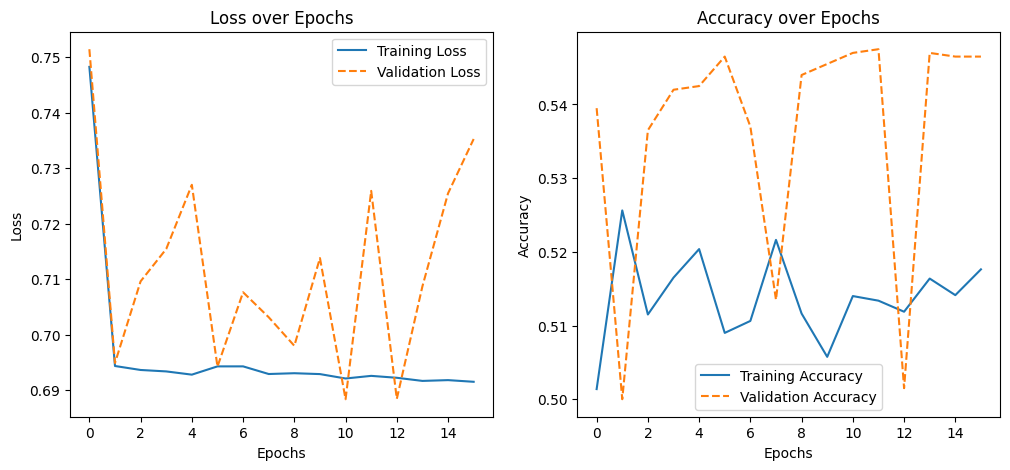

In [23]:
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')

    plt.show()

# Call the function
plot_history(history)

In [24]:
for i in range(1, 10):
    next_item, label = next(fg())
    prediction = model.predict(next_item)
    print("Prediction:", prediction[0][0], "Label", label)

Successful Reads: 10 Failed Reads: 0 Shape Issues: 0


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(10, 20, 2), dtype=float32). Expected shape (None, 10, 20, 2), but input has incompatible shape (10, 20, 2)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(10, 20, 2), dtype=float32)
  • training=False
  • mask=None

In [11]:
# input_shape=(10, 100, 100, 3)
# input_data="Mouth_RGB"
# def ReadFrames(full_path: str, start, end, isTalking):
#     video = cv2.VideoCapture(full_path)
#     frames = []
#     count = 0
#     while count < input_shape[0] and count <= end:
#         video.set(cv2.CAP_PROP_POS_FRAMES, start+count)
#         ret, frame = video.read()
#         if not ret:
#             break
#             # continue
        

#     frames.append(frame)

    
#     res, frame = video.read()

#     if not res:
#         print("failed to read")
    
   
    # video.release()
# Given a file, start and end frame, produce a len10 array of frames